For performing new tracing first import and make Tracer object based on config file settings.
The config file contains locations of images and ROIs for tracing, as well as settings for tracing, quality control and data output and saving.

In [1]:
from tracer import Tracer
import tracing_functions as tr
T=Tracer(r"M:\ChromatinTeam\Images_processing\20200521_Exp328_KSB_Elyra_lowres_A565_bleach_robot\20200523_Exp_328_tracing_config.yaml")

If the analysis has already been run before, we can load the data instead:

In [2]:
import pandas as pd
import numpy as np
import os
import image_processing_functions as ip
wdir = r"M:\ChromatinTeam\Images_processing\20200521_Exp328_KSB_Elyra_lowres_A565_bleach_robot\03_Analysis"+os.sep
traces = pd.read_hdf(wdir+"20200521_Exp328_ELYRA_BS32-40_bleach_traces.h5")
imgs=np.moveaxis(ip.read_tif_image(wdir+'20200521_Exp328_ELYRA_BS32-40_bleach_imgs.tiff'),1,2)
traces_beads = pd.read_hdf(wdir+"20200521_Exp328_ELYRA_BS32-40_beads_traces_beads.h5")
imgs_beads=np.moveaxis(ip.read_tif_image(wdir+'20200521_Exp328_ELYRA_BS32-40_beads_imgs_beads.tiff'),1,2)

Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [67]:
traces.shape

(750, 11)

In [68]:
traces.query('trace_ID == 16')

BG            A  \
trace_ID img_name               roi_ID cell_ID frame                            
16       seq_run_DE_2_W0002__dc 7      3       0      304.699363  1205.536508   
                                               1      147.456026   813.867604   
                                               2      153.056248   675.385243   
                                               3      151.409355   614.926521   
                                               4      136.395533   188.590821   
                                               5      132.761249   302.994093   
                                               6      147.585322   351.817655   
                                               7      117.979227   218.068838   
                                               8      257.165948   517.928815   
                                               9      172.632123   366.166994   

                                                          z_px       y_px  \
trace_ID img_name               roi_ID cell_ID frame                        
16       seq_run_DE_2_W0002__dc 7      3       0      6.458497  29.358779   
                                               1      6.041676  29.211289   
                                               2      7.140350  27.830027   
                                               3      7.501246  28.400840   
                                               4      5.618392  27.960057   
                                               5      7.074681  28.978647   
                                               6      6.281120  30.363636   
                                               7      5.551085  31.101177   
                                               8      5.930747  29.618263   
                                               9      6.520282  29.554463   

                                                           x_px     sigma_z  \
trace_ID img_name               roi_ID cell_ID frame                          
16       seq_run_DE_2_W0002__dc 7      3       0      27.936468  257.401464   
                                               1      29.852082  252.816706   
                                               2      32.852349  270.139219   
                                               3      35.317032  273.756270   
                                               4      35.494058  273.291210   
                                               5      34.227650  255.201758   
                                               6      34.680971  351.194809   
                                               7      33.454793  250.090892   
                                               8      34.000292  372.739732   
                                               9      33.829221  385.689065   

                                                        sigma_xy            z  \
trace_ID img_name               roi_ID cell_ID frame                            
16       seq_run_DE_2_W0002__dc 7      3       0      113.055767  1291.699391   
                                               1      110.291752  1208.335203   
                                               2      115.561627  1428.070014   
                                               3      116.328671  1500.249194   
                                               4      117.392964  1123.678306   
                                               5      111.498355  1414.936199   
                                               6      151.331223  1256.224003   
                                               7      108.706525  1110.216933   
                                               8      190.442238  1186.149345   
                                               9      186.050882  1304.056382   

                                                                y  \
trace_ID img_name               roi_ID cell_ID frame                
16       seq_run_DE_2_W0002__dc 7      3       0      3023.954240   
                                   

We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

In [77]:
tr.plot_traces(traces,[13])

Let us get some more statistics on our traces:

In [70]:
import plotly.express as px
px.histogram(traces.groupby(level='trace_ID').sum(), x='QC', histnorm='percent', width=500)

In [71]:
px.bar(traces.groupby(level='frame').sum(), y='QC', width=500)

In [75]:
#px.bar(traces.query('QC==1').groupby(level='frame').mean(), y='A', width=500)
px.bar(traces.query('QC==1').groupby(level='frame').mean(), y='BG', width=500)

Visualize fits on top of actual image data using napari.

In [76]:
import napari
points=tr.points_for_overlay(traces.query('QC==1'))
with napari.gui_qt():
    viewer = napari.view_image(np.max(imgs,axis=2), contrast_limits=(100,1000))
    viewer.add_points(points[:,(0,1,3,4)], size=[0,0,1,1], face_color='blue', symbol='cross', n_dimensional=True)

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [37]:
traces_long = tr.tracing_length_qc(traces, min_length=6)
pwds_long = tr.pwd_calc(traces_long)

In [50]:
print('Number of traces in analysis: ', pwds_long.shape[0])
pwds_mean=np.clip(np.round(-np.nanmean(pwds_long, axis=0),0).astype(int),-600,0)

import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Number of traces in analysis:  48


C:\Users\ellenberg\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning:

Mean of empty slice



Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [41]:
pairs = tr.trace_analysis(traces_long, pwds_long)
pairs.sort_values(by=['pwd_pcc'], ascending=False).head()

,idx1,idx2,A,A_idx,B,B_idx,B_aligned,B_aligned_idx,aligned_mse,pwd_mse,pwd_pcc
309,11,14,"[[3269.5173687133392, 3034.5768585951582, 1263...","Int64Index([0, 3, 4, 5, 6, 7], dtype='int64', ...","[[3372.780942083843, 2827.5458111068533, 1463....","Int64Index([0, 3, 4, 5, 6, 7], dtype='int64', ...","[[3269.2182985722725, 3034.2861788912965, 1263...","Int64Index([0, 3, 4, 5, 6, 7], dtype='int64', ...",0.039531,0.127535,0.999999
371,13,52,"[[3364.96545356493, 2955.8542435742565, 1502.4...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[2897.6449552369127, 3408.3829472656557, 1410...","Int64Index([0, 1, 2, 3, 4, 5, 6, 7], dtype='in...","[[3520.3734501304284, 2929.5962485157384, 1611...","Int64Index([0, 1, 2, 3, 4, 5, 6, 7], dtype='in...",6517.177762,11848.362774,0.896976
461,15,71,"[[3340.7962243664992, 2619.2260193339434, 1413...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3260.4851954598003, 3588.7906880389914, 1375...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3335.7588642167407, 2778.910013552515, 1438....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...",7141.943676,21308.025732,0.896081
1112,62,71,"[[3082.524895088513, 3466.0117032791372, 1777....","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3260.4851954598003, 3588.7906880389914, 1375...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...","[[3135.231002070731, 3410.435584584154, 1769.9...","Int64Index([0, 1, 2, 3, 4, 5, 6], dtype='int64...",6291.105097,8898.957911,0.886299
48,2,5,"[[3604.6435687814583, 3596.1946351217316, 1513...","Int64Index([0, 1, 3, 4, 6, 7], dtype='int64', ...","[[3225.444000449443, 3731.52723869987, 1303.52...","Int64Index([0, 1, 3, 4, 6, 7], dtype='int64', ...","[[3641.1421763562366, 3627.892670593686, 1790....","Int64Index([0, 1, 3, 4, 6, 7], dtype='int64', ...",19973.025917,61590.215539,0.884515


We can visualize the aligned traces by their index in the pair matrix.

In [51]:
tr.plot_paired_traces(pairs, 371)

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

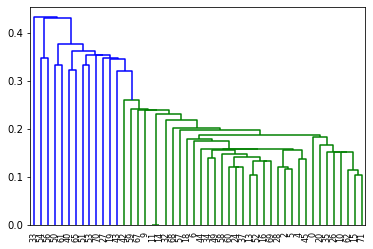

In [44]:
Z = tr.trace_clustering(pairs, metric='pwd_pcc')

In [45]:
## Load R

## Before starting
# install R (tested on R 4.0.0)
# in cmd
# pip install rpy2
# add "C:\Program Files\R\R-4.0.0\bin\x64" to environment variables
import os
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.0.0'
%load_ext rpy2.ipython

# print(pairs.head)
# print(traces.head)
pairs_df = pairs.astype(str)
traces_df = traces.copy()

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [59]:
%%R
# import df from global environment
# make default figure size 5 by 5 inches with 200 dpi resolution
library("abind")
library("tidyr")
# library("geomorph")
library("shapes")

# Define functions in R

# Run Generalized Procrustes analysis
shapes_gpa = function(traces_df, group_IDs_i){
    
    # Clean up the traces_df after import to R
    df = gsub("[(]", "", rownames(traces_df))
    df = gsub("[)]", "", df)
    df = strsplit(x = df, split = ",")
    df = do.call(rbind, lapply(df, function(x){
        data.frame(trace_ID = x[1], img_name = x[2], roi_ID = x[3], cell_ID = x[4], frame = x[5])
    }))
    traces_df = cbind(df, traces_df)
    rownames(traces_df) = NULL
    remove(df)
    
    # Analysis of traces_df
    # find traces belonging to each group
    bool = sapply(traces_df$trace_ID, function(id){
    any(id == group_IDs_i)
    })
    out = subset(traces_df, bool)
  
    # remove QC points 
    out = subset(out, QC == 1)
  
    # Add NA if missing data
    all_frames = unique(out$frame)
    out$frame = factor(out$frame, levels = all_frames) # add facrors to frame
    out = split(out, f = out$trace_ID) # split to list by trace_ID
    out = lapply(out, function(x){complete(x, frame)})# add NA if missing frames
    out = lapply(out, function(x){as.matrix(x[c("x", "y", "z")], ncol = 3)}) # extract x y z and convert to list of 2D matrix  
    
    # Make empty matrix and populate with data
    # 2D plane is each trace, z plane in different traces
    out_3d = array(NA, dim = c(nrow(out[[1]]),3,length(out)))
    for (j in seq_along(out)) {
        out_3d[,,j] = out[[j]] 
    }
    
   
   
    # Estimate the missing values with TPS = thin-plate spline or Reg = multivariate regression
    if(any(is.na(out_3d))){
        out_3d = geomorph::estimate.missing(out_3d, method = "TPS")
    }

    
    # Generalized Procrustes analysis
    # gp = gpagen(out_3d, PrinAxes=FALSE, Proj=TRUE)
    gp = procGPA(x = out_3d)
    
    # summary(gp)
    # plot(gp)
    df = data.frame(gp$mshape)
    colnames(df) = c("x", "y", "z")
    # df$Exchange = paste0("Frame ", 1:nrow(df))
    df$idx = 1
    df$QC = 1
    df$frame = all_frames
    return(df)
}
print("added: shapes_gpa function")


[1] "added: shapes_gpa function"


In [60]:
# input variables to R
%R -i traces_df # input
%R group_IDs_i = c(13, 52, 16, 69)
# %R print(traces_df)

# Clean up traces after import from pandas
# Clean up the traces_df after import to R


# compute GPA
# %R print(geomorph_gpa)
%R shapes_gpa_out = shapes_gpa(traces_df = traces_df, group_IDs_i = group_IDs_i)

# export to python
%R -o shapes_gpa_out
shapes_gpa_out
shapes_gpa_out=shapes_gpa_out.set_index(['idx','frame'])
#geomorph_gpa_out = pd.concat(geomorph_gpa_out, axis=1)
tr.plot_traces(shapes_gpa_out,[1])

We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.